# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 61     | Studienummer |
| :-------------|:-------------|
| Student Daantje Bunschoten | 6375154 |
| Student Jesse Langenberg | 6290116 |

In [ ]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

In [ ]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print de exponent op een nette manier.

De index waar z = 0m is 50


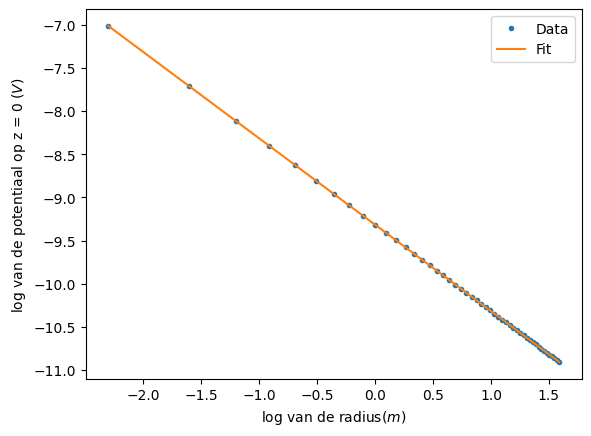

De exponent is -1.00


In [6]:
from scipy.optimize import curve_fit

#1. z = 0m op index 50 
tolerantie = 1e-12
z_0 = np.where(np.abs(z)<tolerantie)[0][0]
print("De index waar z = 0m is" , z_0)
#2 zorgen dat de arrays van dezelfde vorm zijn
r_plot = r[1:]
Vplot = V[50,:]
V_plot = Vplot[1:]

#functie om aan te fitten
def Functie(x,a,b):
    return a*x + b 

#fit
vals,cov = curve_fit(Functie,np.log(r_plot),np.log(V_plot))
x_fit = np.log(r_plot)
y_fit = Functie(x_fit,*vals)

#plot
plt.figure()
plt.plot(np.log(r_plot),np.log(V_plot),'.',label="Data")
plt.plot(x_fit,y_fit,'-',label = "Fit")
plt.xlabel("log van de radius($m$)")
plt.ylabel("log van de potentiaal op z = 0 ($V$)")
plt.legend()
plt.show()

#exponent print
print(f"De exponent is {vals[0]:.2f}")


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

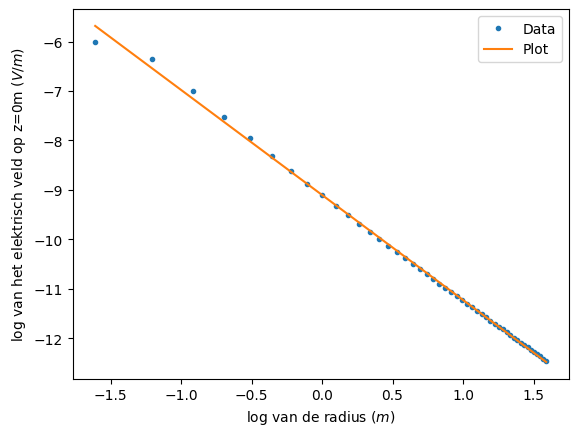

De exponent is ongeveer -2.13


In [7]:
#zorgen dat de arrays van dezelfde vorm zijn (50, want bij index 50 is z = 0m)
rplot = r_plot[1:]
E_plot = Er[50,:]

#functie om aan te fitten
def Functie(x,a,b):
    return a*x + b 

#fit
vals,cov = curve_fit(Functie,np.log(rplot),np.log(E_plot))
x_fit = np.log(rplot)
y_fit = Functie(x_fit,*vals)

#plot
plt.figure()
plt.plot(np.log(rplot),np.log(E_plot),'.',label= "Data")
plt.plot(x_fit,y_fit,"-",label = "Plot")
plt.xlabel("log van de radius ($m$)")
plt.ylabel("log van het elektrisch veld op z=0m ($V/m$)")
plt.legend()
plt.show()

#print de exponent
print(f"De exponent is ongeveer {vals[0]:.2f}")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [8]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

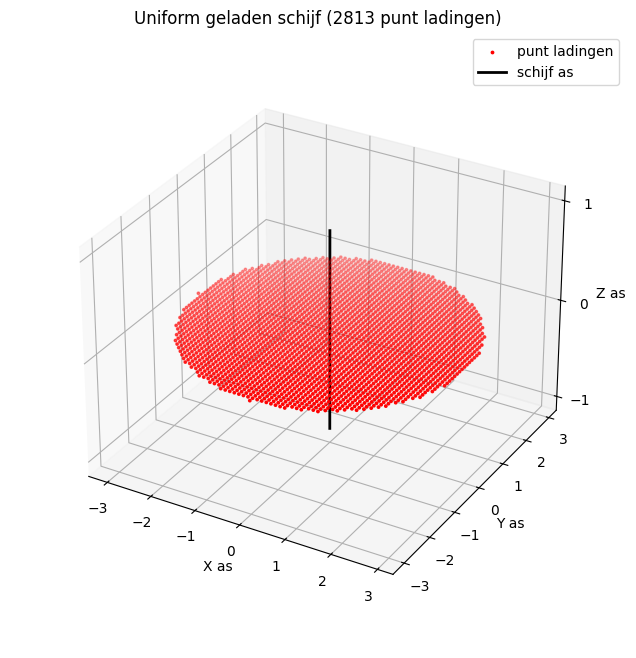

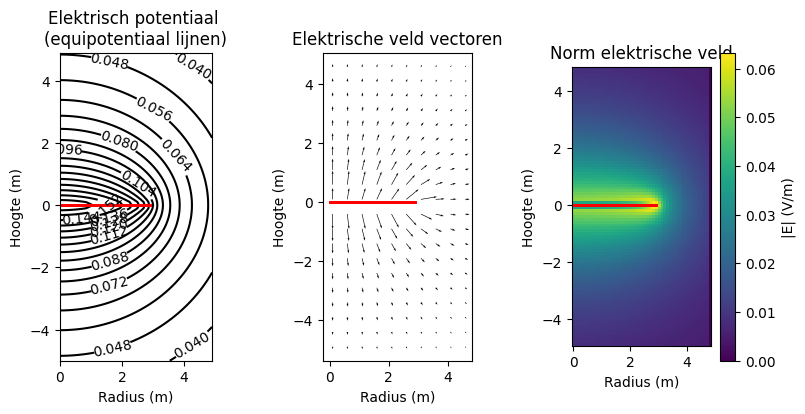

In [9]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1- Hoe hoger de disk radius variabele, hoe langer het runnen duurt, dit komt omdat er meer puntladingen worden geplaatst. Hierdoor wordt de schijf groter. Als de radius 0 is dan is er geen schijf met lading, dus er komt dan ook niets meer in de plot.  
2- De gridstap is de dichtheid van de puntladingen in de schijf. Als je de gridsstap verhoogt, dan worden er minder puntladingen geplaatst, de simulatie is dan ook weer sneller klaar, want er worden minder puntladingen uitgerekend.  
3- Als je de coordinatie van de z-as verhoogt, dan heeft dat geen ivloed op de schijf, maar het verhoogt wel het elektrische veld/veldlijnen

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [10]:
# bereken de ladingsdichtheid van de schijf (aantal punten)*(lading/punt)/(oppervlakte schijf)) = ladingsdichtheid [C/m^2]
sigma =( number_point_charges_on_disk *charge_one_point) /(np.pi*disk_radius**2) 
print(f"De ladingsdichtheid van de schijf is {sigma:.2e} C/m\u00B2")

De ladingsdichtheid van de schijf is 9.95e-13 C/m²


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

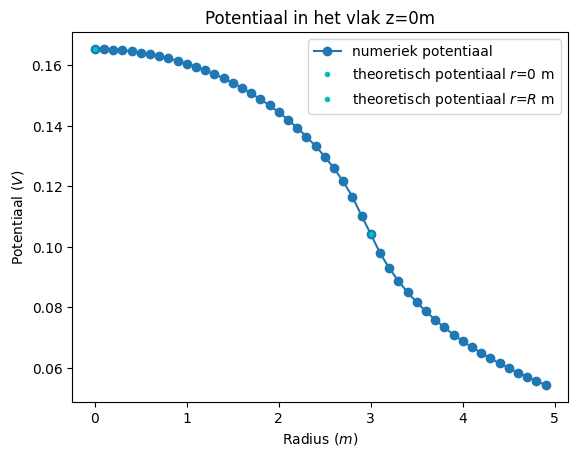

In [11]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.

#index van z = 0m
idx_z_zero = np.where(abs(z) < 1e-10)[0][0]
r_R_index = np.where(r == max(r))

#alle waarden van de potentiaal in het vlak z = 0m
V_0 =  V[idx_z_zero,:]
V_R =  V_0[np.argmin(abs(r-disk_radius))]
r_R =  disk_radius

#plot
plt.title(f"Potentiaal in het vlak z=0m")
plt.plot(r, V_0, "o-", label="numeriek potentiaal")
plt.plot(0, V_0[np.argmin(abs(r - 0))], "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Radius ($m$)")
plt.ylabel("Potentiaal ($V$)")
plt.show()


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


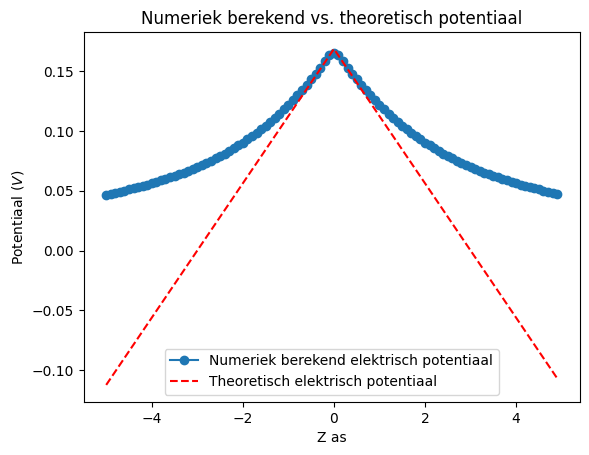

In [12]:
# index r = 0m
index_r_0 = np.argmin(abs(r))
V_numeriek = V[:,index_r_0]
V_theorie = (sigma)/(2*epsilon0) * (disk_radius - np.abs(z))

#plot
plt.figure()
plt.plot(z,V_numeriek,"o-",label = "Numeriek berekend elektrisch potentiaal")
plt.plot(z,V_theorie,'r--',label = "Theoretisch elektrisch potentiaal")
plt.xlabel("Z as")
plt.ylabel("Potentiaal ($V$)")
plt.legend()
plt.title("Numeriek berekend vs. theoretisch potentiaal")
plt.savefig('V_numeriekvstheoretisch_Z_axis_plot.png')
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

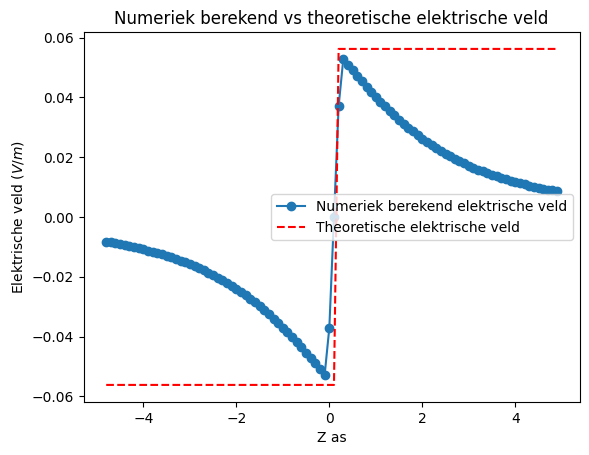

In [13]:

z_Eplot = z[2:]
E_numeriek = Ez[:,index_r_0]
E_theoretisch = sigma / (2*epsilon0)*(z_for_E/np.abs(z_for_E))

plt.figure()
plt.plot(z_Eplot,E_numeriek,"o-",label = "Numeriek berekend elektrische veld")
plt.plot(z_Eplot,E_theoretisch*np.ones_like(z_Eplot),"r--",label="Theoretische elektrische veld")
plt.xlabel("Z as")
plt.ylabel("Elektrische veld ($V/m$)")
plt.legend()
plt.title("Numeriek berekend vs theoretische elektrische veld")
plt.savefig("E_numeriekvstheoretische_Z_as_plot.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1- Het elektrische veld van een uniform geladen schijf benadert dat van een oneindig geladen plaat in de z as.  
2- Het Theoretische veld heeft maar een absolute waarde, terwijl in de werkelijkheid het elektrische veld afneemt naarmate het verder van de z as is.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

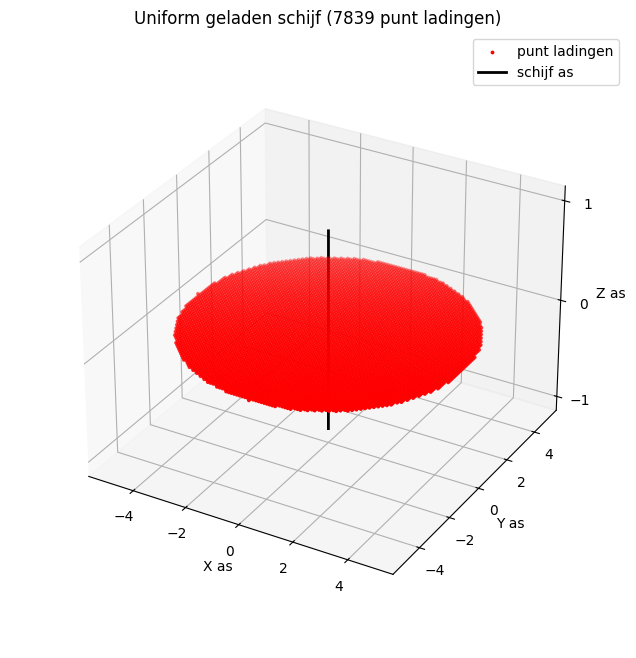

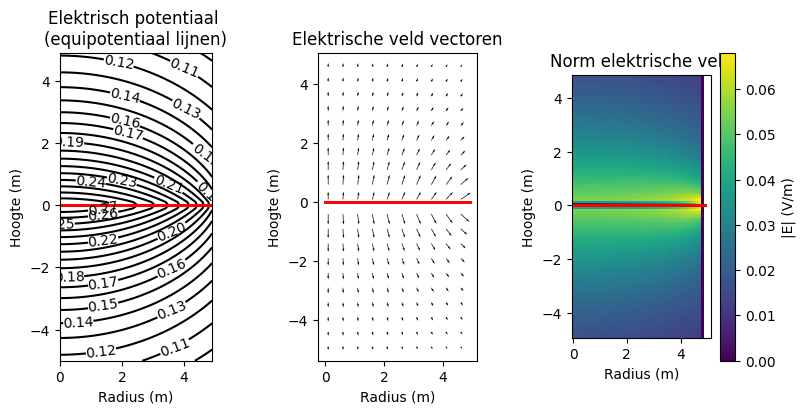

In [14]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 5  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

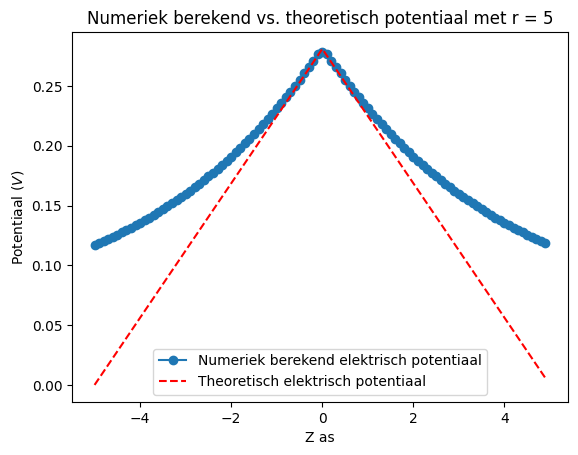

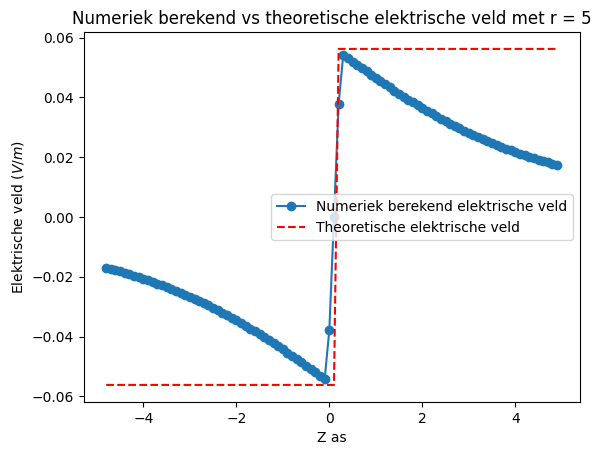

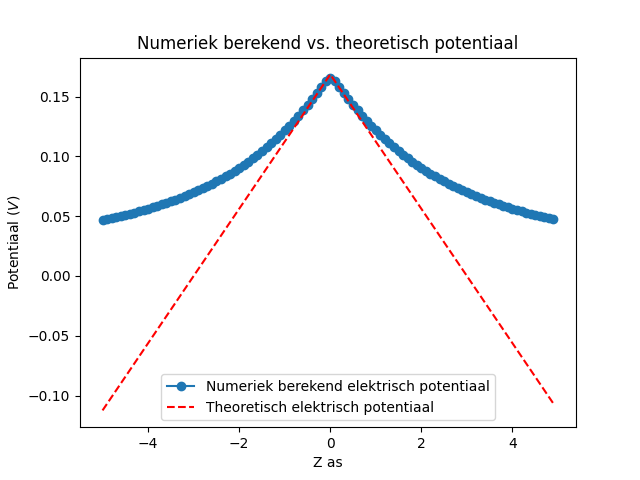

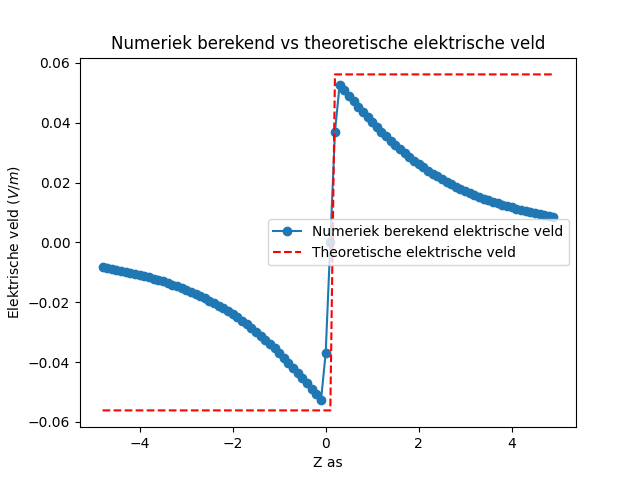

In [15]:
#2d
index_r_0 = np.argmin(abs(r))
V_numeriek = V[:,index_r_0]
V_theorie = (sigma)/(2*epsilon0) * (disk_radius - np.abs(z))

plt.figure()
plt.plot(z,V_numeriek,"o-",label = "Numeriek berekend elektrisch potentiaal")
plt.plot(z,V_theorie,'r--',label = "Theoretisch elektrisch potentiaal")
plt.xlabel("Z as")
plt.ylabel("Potentiaal ($V$)")
plt.legend()
plt.title("Numeriek berekend vs. theoretisch potentiaal met r = 5")
plt.savefig('V_numeriekvstheoretisch_Z_axis_plot_r=5.png')
plt.show()

#2e
z_Eplot = z[2:]
E_numeriek = Ez[:,index_r_0]
E_theoretisch = sigma / (2*epsilon0)*(z_for_E/np.abs(z_for_E))

plt.figure()
plt.plot(z_Eplot,E_numeriek,"o-",label = "Numeriek berekend elektrische veld")
plt.plot(z_Eplot,E_theoretisch*np.ones_like(z_Eplot),"r--",label="Theoretische elektrische veld")
plt.xlabel("Z as")
plt.ylabel("Elektrische veld ($V/m$)")
plt.legend()
plt.title("Numeriek berekend vs theoretische elektrische veld met r = 5")
plt.savefig("E_numeriekvstheoretische_Z_as_plot_r=5.png")
plt.show()

display(Image(filename="V_numeriekvstheoretisch_Z_axis_plot.png"))
display(Image(filename="E_numeriekvstheoretische_Z_as_plot.png"))


##### Antwoorden 2g

Je kan zien dat bij een hogere radius de potentiaal minder snel afwijkt van de theoretische potentiaal, en ook bij het elektrische veld zie je dat bij een grotere radius het berekende elektrische veld meer gaat lijken op het theoretische veld. Dit laat zien dat hoe groter de radius hoe beter de theoretishce benadering gaat passen.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

$$ \mathbf{E_{oneindig}} = \frac{\sigma}{2\epsilon_0}$$

$$ \mathbf{0.1\cdot{E_{oneindig}}} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] $$

$$ 0.1 = 1 - \frac{z}{\sqrt{R^2+z^2}} $$

$$ z^2\dot{(1.1^2-1)}=R^2+z^2$$

$$ z = \frac{R}{0.21} $$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

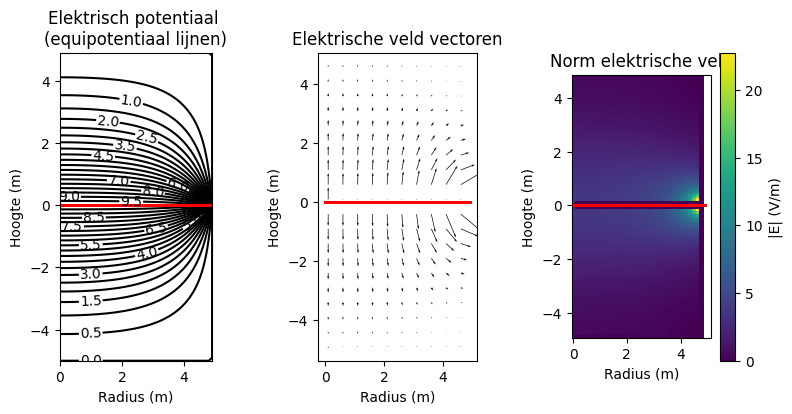

In [16]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

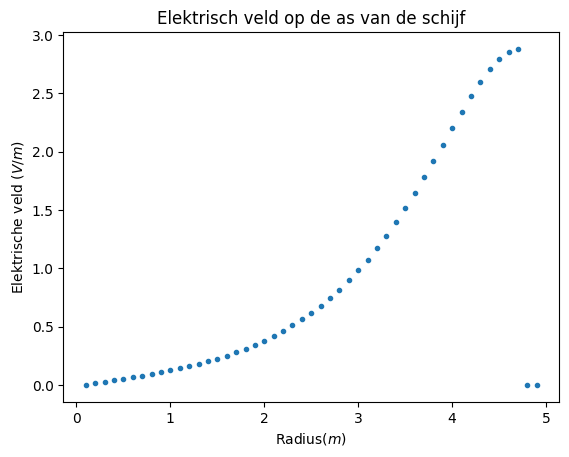

De norm van het elektrische veld op de as heel dicht bij het midden van de schijf is ongeveer 5.28e-01 V/m


In [17]:
z_0_idx = np.where(z == 0)

Er_plot = Er[64,:]
r_plot = r[1:]

plt.figure()
plt.plot(r_plot,Er_plot,".")
plt.title("Elektrisch veld op de as van de schijf")
plt.xlabel("Radius($m$)")
plt.ylabel("Elektrische veld ($V/m$)")
plt.show()

norm_midden = normE[np.argmin(r)][0]
print(f"De norm van het elektrische veld op de as heel dicht bij het midden van de schijf is ongeveer {normE[np.argmin(r)][0]:.2e} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

$$ σ(0)=\frac{\epsilon_0 V_0}{2 \pi R}​​ $$

In [18]:
Sigma_0 = epsilon0*V1/(2*np.pi*disk_radius)

print(f"De benadering van de oppervlaktelading in het midden van de schijf is {Sigma_0:.2e} C/m\u00B2")

De benadering van de oppervlaktelading in het midden van de schijf is 2.82e-12 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


De totale lading op de schijf is 3.5415999999999994e-09 C
De verhouding tussen de geleidende schijf en de uniform geladen schijf is 0.0625


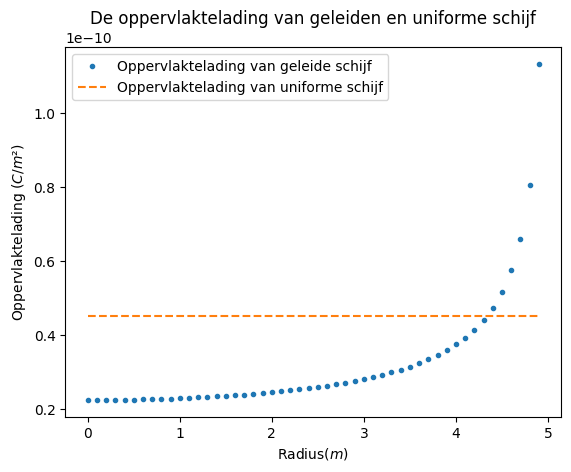

In [19]:
#1 -De formule geintegreerd over de oppervlakte 
Q_tot = 8*epsilon0*disk_radius*V1
print(f"De totale lading op de schijf is { Q_tot} C") 

#2
sigma_uniform = Q_tot / (np.pi * disk_radius**2)
verhouding = Sigma_0/sigma_uniform

print(f"De verhouding tussen de geleidende schijf en de uniform geladen schijf is {verhouding}")

#3
r_plot = r
oppervlaktelading = Q_tot / (2 * np.pi*disk_radius*np.sqrt(disk_radius**2 - r_plot**2))
plt.figure()
plt.plot(r_plot,oppervlaktelading,".",label="Oppervlaktelading van geleide schijf")
plt.plot(r,sigma_uniform*np.ones_like(r),"--",label="Oppervlaktelading van uniforme schijf")
plt.title("De oppervlaktelading van geleiden en uniforme schijf")
plt.xlabel("Radius($m$)")
plt.ylabel(f"Oppervlaktelading ($C/m\u00B2$)")
plt.legend()
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [20]:
# 1
r_idx_maxsigma = np.where(oppervlaktelading == max(oppervlaktelading))[0]
E_max = normE[r_idx_maxsigma,0][0]
print(f"Het maximale elektrische veld op de geleide schijf is {E_max:.2f} V")

#2
idx_ruimte = np.where(normE == E_max)
r_plaats = r[idx_ruimte[0]][0]
z_plaats = z[idx_ruimte[1]][0]

print(f"Het maximale elektrische veld bevindt zich op r={r_plaats} m en z={z_plaats} m")

#3
verschil_elektrischveld = E_max - norm_midden
print(f"Het verschil tussen het maximale elektrische veld en het elektrische veld in het midden van de schijf is {verschil_elektrischveld:.2f} V")


Het maximale elektrische veld op de geleide schijf is 0.00 V
Het maximale elektrische veld bevindt zich op r=4.9 m en z=-5.0 m
Het verschil tussen het maximale elektrische veld en het elektrische veld in het midden van de schijf is -0.53 V


##### Antwoord 3d.5

Doordat de oppervlakte lading niet uniform is maar groter is aan de buitenkant van de schijf, is het elektrische veld ook groter aan de buitenkant van de schijf. 

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

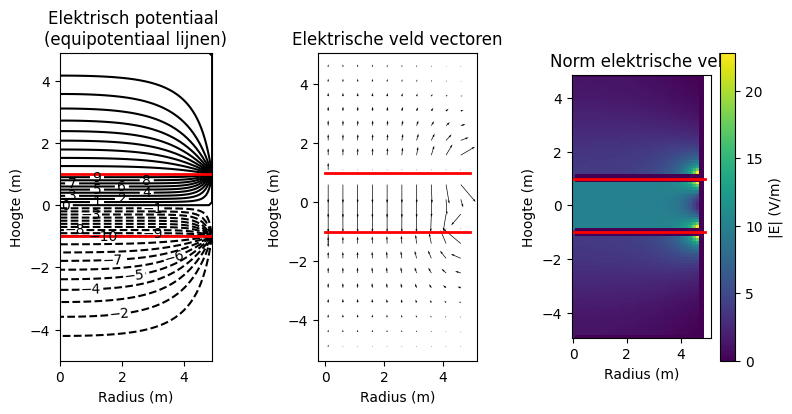

In [21]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


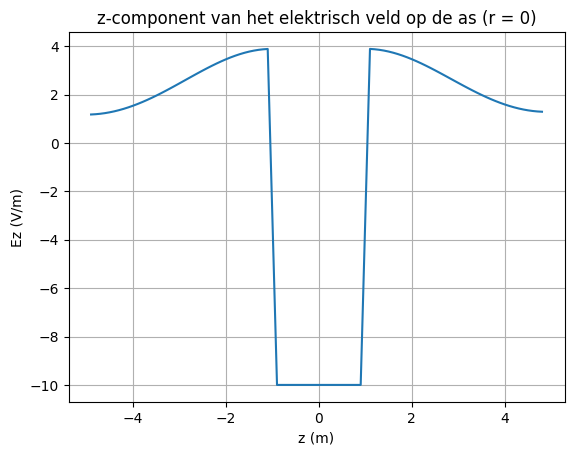

In [22]:

# Plot van Ez op de as (r = 0)
# index van r = 0
idx_r0 = 0

# Ez op de as
Ez_axis = Ez[:, idx_r0]


plt.figure()
plt.plot(z_for_E, Ez_axis)
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("z-component van het elektrisch veld op de as (r = 0)")
plt.grid()
plt.show()

###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. Voor een elektrische plaat met gelijk verdeelde ladingsdichtheid geldt: E = σ / (2 * ε₀). Omdat we werken met 2 platen, tellen deze velden tussen de platen samen op. Dus geldt: E_(tussen platen) = σ / (2*ε₀) + σ / (2*ε₀) = σ/ε₀. Daarnaast geldt dat buiten beide platen het elektrische veld 0 is, want de platen heffen elkaars elektrische veld op. Dus E_(buiten platen) = 0.
De standaardformule voor een elektrisch veld in een condensator: E = ΔV / d. Waarbij ΔV staat voor het spanningsverschil tussen de twee platen, en d de afstand tussen de twee platen is. In onze simulatie geldt: ΔV = V_1 - V_2 = 10 - -10 = 20 V. De afstand d tussen beide platen is 2 m. Dan is het elektrische veld tussen de twee platen: E = 20 / 2 = 10 V / m.

Omdat het potentiaal daalt van +10 naar −10 wanneer z toeneemt: dV / dz < 0, geldt: Ez = −dV / dz < 0.


schets met 2 regio's, tussen de platen in en rondom beide platen:


![Geleidende platen](figures/Geleidendeplaten.png)


2. Uit de hierboven beschreven grafiek zien we, omdat z van -1 tot 1 gaat, dat het elektrisch veld E_z -10 V / m is. Het theoretische elektrische veld was ook - 10 V / m, want: E_z = - dV / dz = - (10 - -10) / 2 = -10 V / m. Het theoretische en gesimuleerde elektrische veld komt dus goed overeen.

3. Een enkele geleidende schijf heeft geen 'tegenschijf', waardoor het elektrische veld bij een enkele schijf zich alle kanten op verspreid. Daarom komt de gesimuleerde waarde bij een enkele schijf (vraag 3a) lager uit dan bij twee schijven. De configuratie met twee schijven heeft als voordeel dat er een bijna-uniform veld tussen de schijven bestaat, dat de veldsterkte redelijk constant is tussen de schijven, en dat er weinig randinvloeden zijn in het centrale gebied tussen de schijven.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

#### Antwoorden 4c

1. Er geldt bij beide schijven: σ = ​ε₀⋅∣E∣. Dit wordt:  $8.854⋅10^{−12} \cdot 10$ = $8.854⋅10^{-11}$ C / $m^2$. Dus de oppervlakte lading op de binnenzijde van een van de schijven is: $8.854⋅10^{-11}$ C / $m^2$.

2. De oppervlakte van een schijf is π⋅$R^2$. R is bij ons 5 m, dus is de oppervlakte van een schijf: π⋅25. De totale verwachte lading op de binnenzijde van de 2 schijven is dan: 2⋅π⋅25⋅$8.854⋅10^{-11}$ = 1.39⋅10^{-8} C.

3. Voor de capaciteit C geldt: C = ​ε₀A/d. Hier geldt: C = ​$8.854⋅10^{−12} \cdot 25 \cdot π$/2 = $3.47⋅10^{-10}$ F.

In [23]:
#4c
sigma = 8.854*(10**-11) # C/m^2
totale_lading = 1.39*10**-8 # C
capaciteit = 3.47*10**-10 # F

print(f"De oppervlaktelading op de binnenzijde van één schijf is {sigma:.2e} C/m^2.")
print(f"De totale lading op beide schijven samen is {totale_lading:.2e} C.")
print(f"De capaciteit van dit systeem is {capaciteit:.2e} F.")

De oppervlaktelading op de binnenzijde van één schijf is 8.85e-11 C/m^2.
De totale lading op beide schijven samen is 1.39e-08 C.
De capaciteit van dit systeem is 3.47e-10 F.


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. Bij een ideale situatie met twee oneindig grote platen zit alle lading aan de binnenzijden van de platen. Buiten de platen is het elektrisch veld dan nul, omdat de velden van beide platen elkaar daar precies opheffen. Aangezien de oppervlakteladingsdichtheid gegeven wordt door σ = ​ε₀ * E, betekent een elektrisch veld van 0 ook dat de oppervlaktelading aan de buitenkant nul is. In het geval van eindige schijven (zoals in de simulatie) is de oppervlaktelading aan de buitenkant echter niet exact nul. Door het eindige formaat ontstaan er randvelden, waardoor er ook buiten de schijven een klein elektrisch veld aanwezig is. Daardoor verschijnt er aan de buitenzijde een kleine, maar niet-nul ladingsdichtheid.

2. Voor een geleider in elektrostatisch evenwicht geldt dat het elektrisch veld binnenin de geleider nul is. Als dat niet zo zou zijn, zouden vrije ladingen kunnen blijven bewegen. Net buiten het oppervlak van de geleider staat het elektrisch veld overal loodrecht op het oppervlak. De grootte van dat veld wordt gegeven door E = σ / ​ε₀. Er is dus geen tangentiële component van het elektrisch veld aan het oppervlak van een geleider.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [24]:
epsilon0 = 8.854e-12  # F/m

# index van r = 0 (as)
idx_r0 = 0  

# z-index van onderste schijf
z_disk = idx_z2  

# Ez net onder de onderste schijf (buitenkant)
Ez_below = Ez[z_disk - 1,idx_r0]

# Ez net boven de onderste schijf (binnenkant)
Ez_above = Ez[z_disk + 1,idx_r0]

# Ladingsdichtheden volgens: sigma = epsilon0 * E
sigma_bottom = epsilon0 * Ez_below
sigma_top = epsilon0 * Ez_above

#1
print(f"Ez net onder de onderste schijf = {Ez_below:.2e} V/m")

#2
print(f"Ladingsdichtheid onderkant onderste plaat = {sigma_bottom:.2e} C/m^2")

#3
print(f"Ez net boven de onderste schijf = {Ez_above:.2e} V/m")

#4
print(f"Ladingsdichtheid bovenkant onderste plaat = {sigma_top:.2e} C/m^2")
# voor vraag 4f:
# print(f"Ladingsdichtheid bovenkant onderste plaat = {sigma_top:.15e} C/m^2")



Ez net onder de onderste schijf = -3.05e+00 V/m
Ladingsdichtheid onderkant onderste plaat = -2.70e-11 C/m^2
Ez net boven de onderste schijf = -1.00e+01 V/m
Ladingsdichtheid bovenkant onderste plaat = -8.85e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. We zien dat in vraag 4c de theoretische verwachte ladingsdichtheid per schijf: $8.8541878⋅10^{-11}$ C / $m^2$ is, en in de daadwerkelijk berekende ladingsdichtheid is het (na een paar extra decimalen te laten zien) 8.854033 C/m^2. De daadwerkelijke ladingsdichtheid per schijf wijkt dus maar een heel klein beetje af van de theoretische waarde, en daarom wijkt de totale lading op een schijf ook maar een heel klein beetje af van de theoretische waarde, namelijk: $8.8541878⋅10^{-11}⋅π⋅25$ - $8.854033⋅10^{-11}⋅π⋅25$ = $1.22⋅10^{-13}$ C.

2. Niks, want voor de capaciteit C geldt: C = ​ε₀A/d. Hier geldt: C = ​$8.854⋅10^{−12} \cdot 25 \cdot π$/2 = $3.47⋅10^{-10}$ F. We veranderen epsilon_0, A en d niet, dus de afwijking in daadwerkelijke lading op de schijf heeft geen invloed op de capaciteit.

3. Voor de capaciteit C geldt: C = ​ε₀A/d. Wanneer we een kleinere afstand tussen de platen simuleren, wordt de capaciteit groter. Wanneer we een grotere afstand tussen de schijven simuleren, wordt de capaciteit kleiner. Logisch, dit volgt direct uit de formule.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [25]:
# 1 en 2
def vlakkeplaat(A, d, epsilon=8.854e-12):
    C = epsilon * A / d
    return C

# 3 en 4
def cilinder(r1, r2, L, epsilon=8.854e-12):
    C = 2 * np.pi * epsilon * L / np.log(r2 / r1)
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [26]:
# Permittiviteit van verschillende materialen
epsilon0 = 8.854e-12      # F/m (lucht/vacuüm)
epsilon_water = 80 * epsilon0  # F/m Water
epsilon_PVC = 3 * epsilon0     # F/m PVC

# vlakke plaat condensator startwaarden
A_plaat = 0.1*0.1 # 10 cm^2 = 0.01 m^2
d_plaat = 0.001  # 1 mm

# cilinder condensator startwaarden
r1 = 0.009 / 2  # binnenstraal in m
r2 = 0.010 / 2  # buitenstraal in m
L_cil = 0.10    # lengte in m

# 1
C_vlak_lucht = vlakkeplaat(A_plaat, d_plaat, epsilon0)

# 2
C_cil_lucht = cilinder(r1, r2, L_cil, epsilon0)

# 3
C_vlak_lucht_2d = vlakkeplaat(A_plaat, 2*d_plaat, epsilon0)
C_cil_lucht_2d = cilinder(r1, r2*2, L_cil, epsilon0)  # Cilinder: log(r2/r1) verdubbelen ≈ benadering

# 4
C_vlak_water = vlakkeplaat(A_plaat, d_plaat, epsilon_water)
C_cil_water = cilinder(r1, r2, L_cil, epsilon_water)

# 5
C_vlak_PVC = vlakkeplaat(A_plaat, d_plaat, epsilon_PVC)
C_cil_PVC = cilinder(r1, r2, L_cil, epsilon_PVC)

print(f"De capaciteit van de vlakke plaat met lucht is {C_vlak_lucht:.2e} F.")
print(f"De capaciteit van de cilinder met lucht is {C_cil_lucht:.2e} F.")
print(f"De capaciteit van de vlakke plaat met verdubbelde afstand is {C_vlak_lucht_2d:.2e} F.")
print(f"De capaciteit van de cilinder met verdubbelde afstand is {C_cil_lucht_2d:.2e} F.")
print(f"De capaciteit van de vlakke plaat gevuld met water is {C_vlak_water:.2e} F.")
print(f"De capaciteit van de cilinder gevuld met water is {C_cil_water:.2e} F.")
print(f"De capaciteit van de vlakke plaat gevuld met PVC is {C_vlak_PVC:.2e} F.")
print(f"De capaciteit van de cilinder gevuld met PVC is {C_cil_PVC:.2e} F.")


De capaciteit van de vlakke plaat met lucht is 8.85e-11 F.
De capaciteit van de cilinder met lucht is 5.28e-11 F.
De capaciteit van de vlakke plaat met verdubbelde afstand is 4.43e-11 F.
De capaciteit van de cilinder met verdubbelde afstand is 6.97e-12 F.
De capaciteit van de vlakke plaat gevuld met water is 7.08e-09 F.
De capaciteit van de cilinder gevuld met water is 4.22e-09 F.
De capaciteit van de vlakke plaat gevuld met PVC is 2.66e-10 F.
De capaciteit van de cilinder gevuld met PVC is 1.58e-10 F.


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
2. Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [27]:
# 1
# waardes voor vraag 1
C_cyl = 1e-6  # 1 μF
r1_cyl = 0.005 / 2   # 5 mm binnendiameter -> straal in meters
r2_cyl = 0.006 / 2   # 6 mm buitendiameter -> straal in meters

# Bereken L bij cilindrische condensator
L_cyl = C_cyl * np.log(r2_cyl/r1_cyl) / (2 * np.pi * epsilon0)
print(f"De lengte van de cilindercondensator van 1 μF zou: {L_cyl:.2e} m zijn.")

# 2
# waardes voor vraag 2
C_vlak = 1e-6  # F
plaat_breedte = 0.006  # m
A_vlak = plaat_breedte**2  # vierkante condensator
d_plaat = 0.0005  # m

# Bereken benodigde L bij vlakke plaat condensator
# C = ε*A/d; hier A = l^2, dus l = sqrt(C*d/ε)
l_vlak = np.sqrt(C_vlak * d_plaat / epsilon0)
print(f"De zijde van de vierkante vlakke plaat condensator van 1 μF moet {l_vlak:.2e} m zijn.")

De lengte van de cilindercondensator van 1 μF zou: 3.28e+03 m zijn.
De zijde van de vierkante vlakke plaat condensator van 1 μF moet 7.51e+00 m zijn.


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. Nee de antwoorden uit vraag 5c zijn beide niet realistisch: de condensator is in het echt geen meters of honderden meters lang.
2. Fabrikanten rollen platen op, om zo in het oppervlak meer platen kwijt te kunnen. Ook gebruiken ze dunnere diëlektrica, zodat er een hogere capaciteit per volume behaald kan worden, en gebruiken ze materialen met hoge permittiviteit, zodat de lengte van de condensator zo klein mogelijk gemaakt kan worden.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [28]:
# waardes voor alle opdrachten
epsilon0 = 8.854e-12  # F/m
epsilon_r_water = 80
epsilon = epsilon0 * epsilon_r_water

# gegevens achtbaan
v = 70 * 1000 / 3600  # m/s
m_persoon = 70        # kg
aantal_personen = 6   # aantal mensen
m_kar = 500           # kg
V = 10_000            # Volt
d = 0.001             # m (afstand platen)

# 1 
m_treintje = aantal_personen * m_persoon + m_kar

# 2
E = 0.5 * m_treintje * v**2

# 3
C = 2 * E / V**2

# 4
A = C * d / epsilon

# 5

print(f"Massa van het treintje: {m_treintje:.2f} kg")
print(f"Totale kinetische energie: {E:.2e} J")
print(f"Benodigde capaciteit: {C:.2e} F")
print(f"Oppervlakte van een vlakke plaat condensator (water, 1 mm): {A:.2f} m^2")

# 6
print("Deze oppervlakte is extreem groot (>100 m^2). In de praktijk maken ze gebruik van:")
print("meerdere kleine condensatoren in serie/parallel;")
print("opgerolde platen of compacte rollen;")
print("materialen met hoge permittiviteit.")

Massa van het treintje: 920.00 kg
Totale kinetische energie: 1.74e+05 J
Benodigde capaciteit: 3.48e-03 F
Oppervlakte van een vlakke plaat condensator (water, 1 mm): 4910.77 m^2
Deze oppervlakte is extreem groot (>100 m^2). In de praktijk maken ze gebruik van:
meerdere kleine condensatoren in serie/parallel;
opgerolde platen of compacte rollen;
materialen met hoge permittiviteit.


##### Antwoorden 5e

#Zie hierboven in de code

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

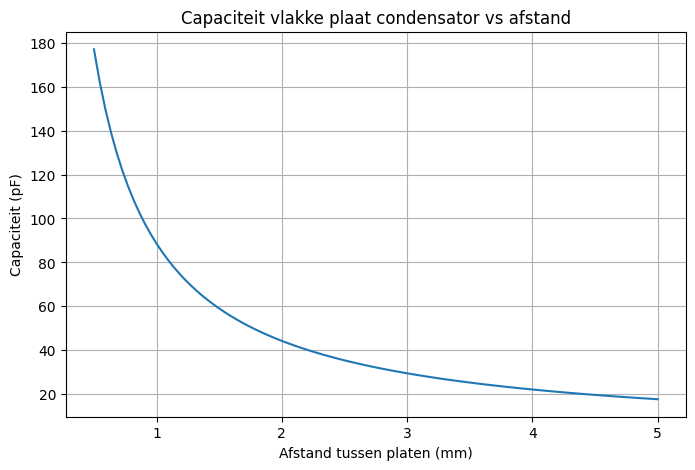

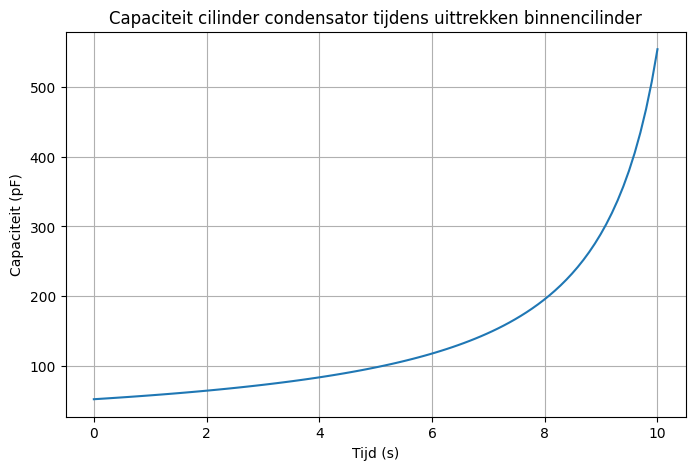

In [29]:
# 1
# gegevens
plaat_l = 0.10  # m
plaat_b = 0.10  # m
A_plaat = plaat_l * plaat_b
d_min = 0.0005  # 0.5 mm
d_max = 0.005   # 5 mm
n_points = 100

# lineair variërende afstand
d_values = np.linspace(d_min, d_max, n_points)
C_vlak = vlakkeplaat(A_plaat, d_values)  # numpy array werkt direct

# plot vlakke plaat
plt.figure(figsize=(8,5))
plt.plot(d_values*1e3, C_vlak*1e12)  # x in mm, y in pF
plt.xlabel("Afstand tussen platen (mm)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit vlakke plaat condensator vs afstand")
plt.grid(True)
plt.show()


# 2
# gegevens
r2 = 0.010 / 2  # m
r1_start = 0.009 / 2  # m
L_cil = 0.10  # m
t_total = 10  # sec
n_steps = 100

# arrays
r1_values = np.linspace(r1_start, r2*0.99, n_steps)  # niet exact tot r2 om log niet nul te maken
C_cil = cilinder(r1_values, r2, L_cil)

# plot cilinder condensator
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, t_total, n_steps), C_cil*1e12)  # y in pF
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit cilinder condensator tijdens uittrekken binnencilinder")
plt.grid(True)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [30]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

De factor is de radius versus de breedte die voorkomt in de ratio. Hoe groter die ratio, hoe groter het verschil in capaciteit tussen de twee capacitors.

Ja, want als we het verschil van de capaciteit van de plaat en disk delen door de capaciteit, en dan het percentage uitrekenen, komen we op percentuele verschillen van 1 tot 4%.

De onzekerheden van de metingen komen redelijk overeen met de percentuele verschillen, want die komen ook ongeveer rond de 1-4 procent uit.


#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

Berekende capaciteit plaatcondensator 88.5 pF
Bepaalde capaciteit plaatcondensator 51.3 pF
De berekende idealiteitsfactor is 0.01


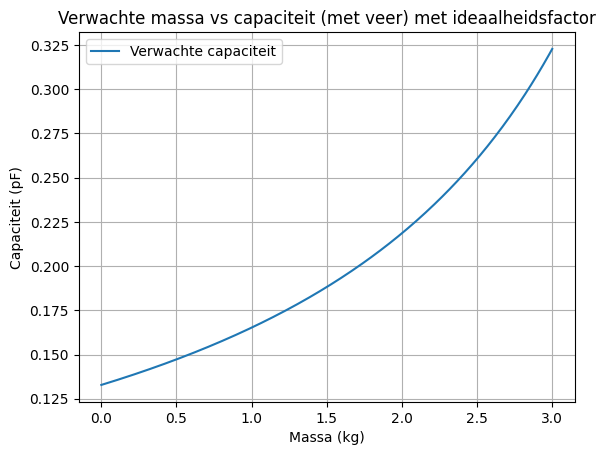

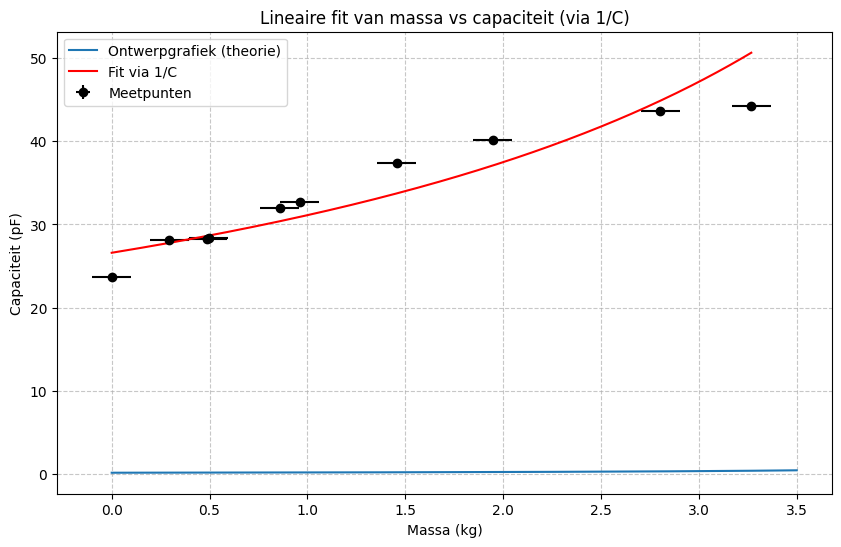

Intercept (1/C bij m=0) : 3.76092e-02 1/pF
Slope (verandering van 1/C met massa) : -5.46720e-03 1/(pF·kg)


In [31]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit
#Code van Jesses oplossing

# plaatcondensator capaciteit

epsilon=8.854e-12
def vlakkeplaat(A, d, e_r):
    C = e_r * A / d
    return C

#berekening met condensator en karton, 10*10 cm^2 oppervlak, dikte karton = 0.0015 meter, ongeveer 2.3 keer permivilliteit van het vacuum.


print(f"Berekende capaciteit plaatcondensator {vlakkeplaat(0.01,0.0015,1.5*epsilon*10**12):.1f} pF")
print(f"Bepaalde capaciteit plaatcondensator 51.3 pF")


def idealiteitsfactor(d,w):
    return d/w

idealiteits_factor_waarde = idealiteitsfactor(0.0015,0.1)
print(f"De berekende idealiteitsfactor is {idealiteits_factor_waarde:.2f}")

# Constanten
epsilon0 = 8.854e-12  # permittiviteit vacuüm (F/m)
A = 0.01              # plaatoppervlak (m²)
d0 = 0.01             # beginafstand zonder massa (m)
k = 5000               # veerconstante (N/m)
g = 9.81              # zwaartekracht (m/s²)

# Massa-array (kg)
m = np.linspace(0, 3, 300)

# Indrukking veer
x = (m * g) / k

# Nieuwe plaatafstand
d = d0 - x

# Capaciteit
C = epsilon0 * A / d *idealiteits_factor_waarde

# Omzetten naar pF
C_pF = C * 1e12

# Plot
plt.plot(m, C_pF, label="Verwachte capaciteit")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")
plt.title("Verwachte massa vs capaciteit (met veer) met ideaalheidsfactor")
plt.grid()
plt.legend()
plt.show()



# data
massa = np.array([0, 0.2952, 0.4884, 0.8588, 0.961,
                  0.4962, 1.457, 1.946, 2.804, 3.268])

capaciteit = np.array([23.7, 28.1, 28.3, 32.0, 32.7,
                       28.4, 37.4, 40.1, 43.6, 44.3])  # pF

# ontwerpgrafiek
epsilon0 = 8.854e-12  # F/m
A = 0.01               # m²
g = 9.81               # m/s²
m_model = np.linspace(0, 3.5, 400)
x = (m_model * g) / k
d = d0 - x
C_model = epsilon0 * A / d
C_model_pF = C_model * 1e12


# fitfunctie: lineair voor 1/C
def inverse_fit(m, intercept, slope):
    return intercept + slope * m  # y = 1/C

# fitwaardes berekenen
y = 1 / capaciteit
popt, pcov = curve_fit(inverse_fit, massa, y)

intercept_fit, slope_fit = popt


# fit
m_fit = np.linspace(0, max(massa), 300)
C_fit = 1 / inverse_fit(m_fit, intercept_fit, slope_fit)

# errorbars
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is


# plotten
plt.figure(figsize=(10,6))
plt.plot(m_model, C_model_pF * idealiteits_factor_waarde, label="Ontwerpgrafiek (theorie)")
plt.errorbar(massa, capaciteit, xerr=x_error, yerr=y_error, fmt='o', color='black', label='Meetpunten')
plt.plot(m_fit, C_fit, color='red', label='Fit via 1/C')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.title('Lineaire fit van massa vs capaciteit (via 1/C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


print(f"Intercept (1/C bij m=0) : {intercept_fit:.5e} 1/pF")
print(f"Slope (verandering van 1/C met massa) : {slope_fit:.5e} 1/(pF·kg)")




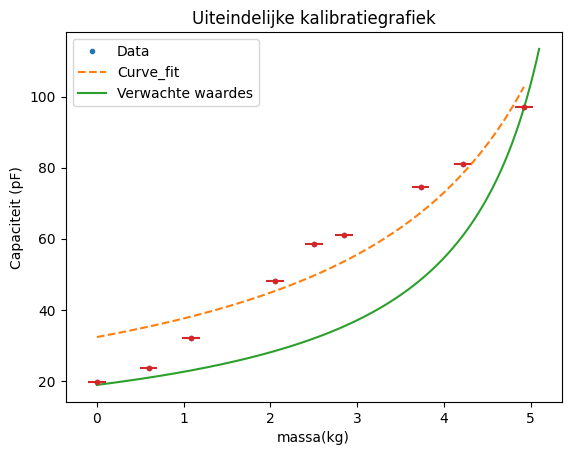

[ 18.89964949  18.91542813  18.93123313  18.94706457  18.96292251
  18.97880701  18.99471815  19.01065599  19.0266206   19.04261205
  19.05863039  19.07467571  19.09074807  19.10684754  19.12297418
  19.13912807  19.15530928  19.17151786  19.18775391  19.20401747
  19.22030863  19.23662745  19.25297401  19.26934837  19.28575061
  19.30218079  19.31863899  19.33512529  19.35163974  19.36818243
  19.38475343  19.40135281  19.41798064  19.434637    19.45132195
  19.46803558  19.48477796  19.50154916  19.51834925  19.53517832
  19.55203643  19.56892366  19.58584009  19.60278579  19.61976083
  19.63676531  19.65379928  19.67086283  19.68795604  19.70507898
  19.72223173  19.73941437  19.75662697  19.77386962  19.79114239
  19.80844537  19.82577862  19.84314224  19.8605363   19.87796088
  19.89541606  19.91290193  19.93041855  19.94796603  19.96554442
  19.98315383  20.00079432  20.01846599  20.03616892  20.05390318
  20.07166886  20.08946605  20.10729483  20.12515528  20.14304749
  20.16097

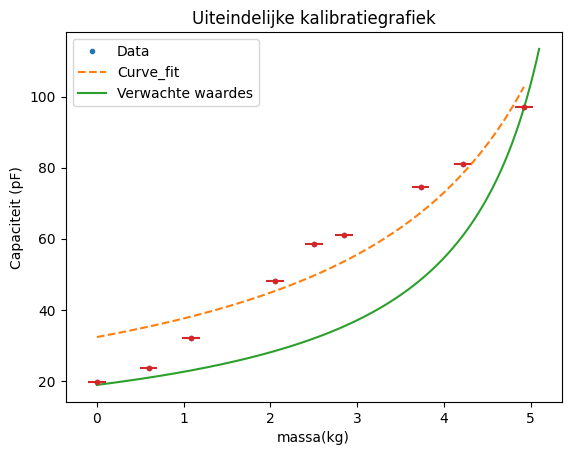

In [29]:
#Code van Daantje - Condensator met een rand van spons, sensor om gewicht te meten

import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

#verwachting uitrekenen
#d_0 blijft gelijk
d_0 = 6e-3 #m 
d_comp = 1e-3 #m
d_verwacht = np.linspace(d_0,d_comp,1000)

# parameters
u = d_0 - d_verwacht
c_veer = 10000
g = 9.81 #m/s^2
epsilon_0=8.854e-12 
A = 0.01

#schalingsfactor  
b = d_verwacht/np.sqrt(A)

#van distance naar massa
def Veer(c_veer,u,g):
    m = (c_veer * u) /g
    return m
def e_r(d,A,epsilon_0,C ):
    epsilon_r =  (d *C) /(epsilon_0 * A)
    return epsilon_r
def capaciteit(V_in,V_uit, frequentie, weerstand):
    C = V_uit/(V_in*frequentie*2*np.pi*weerstand)
    return C
def vlakkeplaat(d,A,epsilon_0,epsilon_r ):
    C = (epsilon_0*epsilon_r * A )/ d
    return C
def nieuw_c(b,A,epsilon_0,epsilon_r):
    C = (epsilon_0*epsilon_r*A)/(np.sqrt(A)*b)
    return C



#E_r uitrekenen van de nieuwe opstelling
C_spons_0 = capaciteit(8,95e-3,100e3,1e3)
e_r_spons= e_r(d_0,A,epsilon_0,C_spons_0)




c_verwacht = vlakkeplaat(d_verwacht,A,epsilon_0,e_r_spons)*1e12
m_verwacht = Veer(c_veer,u,g)

#Metingen
Capaciteit = np.array([19.7,23.6,32,48,58.4,61,74.5,81,97])
massa= np.array([0,
                597.1
                 ,597.1+486.3
                 ,597.1+486.3+967.9  ,2501.6,2849.6,3730.3,4216.3,4922.1 ]) *1e-3




#Poging tot het curve fitten met natuurkunde              
def Functie(x,c_1,c_2,c_3):
 return c_1/(c_2+c_3*x)
var,cov = curve_fit(Functie,massa,Capaciteit)
x_fit = np.linspace(min(massa),max(massa))
y_fit = Functie(x_fit,*var)
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is


#plot van verwachtewaarde, curve_fit en data
plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.plot(m_verwacht,c_verwacht, label="Verwachte waardes")
plt.xlabel("massa(kg)")
plt.ylabel("Capaciteit (pF)")
plt.errorbar(massa,Capaciteit,xerr=x_error,yerr=y_error,fmt='.')
plt.legend()
plt.title("Uiteindelijke kalibratiegrafiek")
plt.show()


nieuw_c_verwacht = nieuw_c(b,A,epsilon_0,e_r_spons)*1e12
print(nieuw_c_verwacht)
plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.plot(m_verwacht,nieuw_c_verwacht, label="Verwachte waardes")
plt.xlabel("massa(kg)")
plt.ylabel("Capaciteit (pF)")
plt.errorbar(massa,Capaciteit,xerr=x_error,yerr=y_error,fmt='.')
plt.legend()
plt.title("Uiteindelijke kalibratiegrafiek")
plt.show()


#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [ ]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*